# **Подгоовка** данных по территории

## 1. Получение кварталов

### 1.1. Получение данных из **OpenStreetMap**. 
Этот шаг можно пропустить, если данные уже существуют.

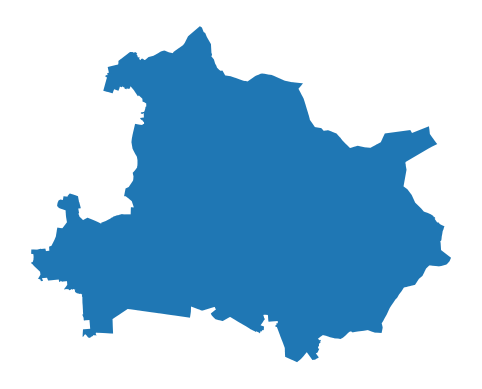

In [1]:
import osmnx as ox

boundaries = ox.geocode_to_gdf('Старобельский район')
boundaries.plot().set_axis_off()

In [2]:
bc_tags = {
    'roads': {
      "highway": ["construction","crossing","living_street","motorway","motorway_link","motorway_junction","pedestrian","primary","primary_link","raceway","residential","road","secondary","secondary_link","services","tertiary","tertiary_link","track","trunk","trunk_link","turning_circle","turning_loop","unclassified",],
      "service": ["living_street", "emergency_access"]
    },
    'railways': {
      "railway": "rail"
    },
    'water': {
      'riverbank':True,
      'reservoir':True,
      'basin':True,
      'dock':True,
      'canal':True,
      'pond':True,
      'natural':['water','bay'],
      'waterway':['river','canal','ditch'],
      'landuse':'basin',
      'water': 'lake'
    }
}

In [4]:
water = ox.features_from_polygon(boundaries.union_all(), bc_tags['water'])
roads = ox.features_from_polygon(boundaries.union_all(), bc_tags['roads'])
railways = ox.features_from_polygon(boundaries.union_all(), bc_tags['railways'])

In [5]:
water = water[water.geom_type.isin(['Polygon', 'MultiPolygon', 'LineString', 'MultiLineString'])].copy()
roads = roads[roads.geom_type.isin(['LineString', 'MultiLineString'])].copy()
railways = railways[railways.geom_type.isin(['LineString', 'MultiLineString'])].copy()

In [6]:
crs = boundaries.estimate_utm_crs()

for gdf in [water, roads, railways, boundaries]:
  gdf.to_crs(crs, inplace=True)

### 1.2. Предварительная обработка входной геометрии

Этот шаг можно пропустить, если входная геометрия уже отсортирована как линии, многоугольники и границы.

In [7]:
roads = roads.reset_index(drop=True)
railways = railways.reset_index(drop=True)
water = water.reset_index(drop=True)

In [8]:
from blocksnet.blocks.cutting import preprocess_urban_objects, cut_urban_blocks

lines, polygons = preprocess_urban_objects(roads, railways, water)

2025-12-10 18:10:46.558 | INFO     | blocksnet.blocks.cutting.preprocessing.core:preprocess_urban_objects:44 - Checking roads schema
2025-12-10 18:10:46.577 | INFO     | blocksnet.blocks.cutting.preprocessing.core:preprocess_urban_objects:51 - Checking railways schema
2025-12-10 18:10:46.581 | INFO     | blocksnet.blocks.cutting.preprocessing.core:preprocess_urban_objects:58 - Checking water schema


### 1.3. **Нарезка** городских кварталов

2025-12-10 18:10:48.019 | INFO     | blocksnet.blocks.cutting.processing.schemas:validate_and_preprocess_gdfs:51 - Checking boundaries schema
2025-12-10 18:10:48.028 | INFO     | blocksnet.blocks.cutting.processing.schemas:validate_and_preprocess_gdfs:55 - Checking line objects schema
2025-12-10 18:10:48.055 | INFO     | blocksnet.blocks.cutting.processing.schemas:validate_and_preprocess_gdfs:62 - Checking polygon objects schema
2025-12-10 18:10:48.063 | INFO     | blocksnet.blocks.cutting.processing.schemas:validate_and_preprocess_gdfs:69 - Checking buildings schema
2025-12-10 18:10:48.064 | WARNING  | blocksnet.blocks.cutting.processing.schemas:validate_and_preprocess_gdfs:71 - Creating empty buildings
2025-12-10 18:10:48.733 | SUCCESS  | blocksnet.blocks.cutting.processing.core:cut_urban_blocks:26 - 2400 blocks are successfully cut


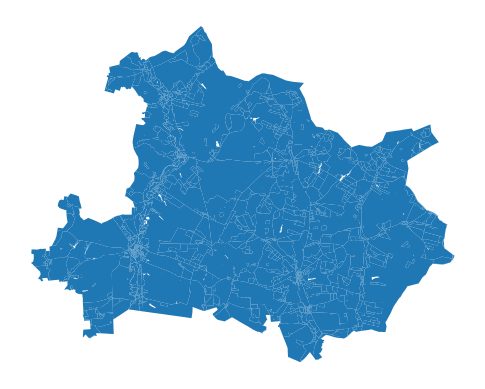

In [9]:
blocks = cut_urban_blocks(boundaries, lines, polygons)
blocks.plot().set_axis_off()

___


## 2. Назначение **землепользования**


### 2.1. Получение данных из OpenStreetMap

Этот шаг можно пропустить, если слой функциональных зон уже получен из государственных источников.

In [10]:
import osmnx as ox

functional_zones = ox.features_from_polygon(boundaries.to_crs(4326).union_all(), tags={'landuse': True})

In [11]:
functional_zones = functional_zones.reset_index(drop=True)[['geometry','landuse']].rename(columns={'landuse': 'functional_zone'})
functional_zones = functional_zones.to_crs(crs)
functional_zones.head()

,geometry,functional_zone
0,POINT (501157.32 5460863.915),military
1,POINT (534535.368 5485423.409),military
2,"POLYGON ((504419.21 5484193.602, 504445.347 54...",forest
3,"POLYGON ((511438.562 5465222.753, 511663.564 5...",farmland
4,"POLYGON ((579865.852 5468681.017, 579875.893 5...",forest



### 2.2. Указание правил

Правила определяют, как столбец `functional_zone` будет отображаться в `LandUse`.

In [12]:
from blocksnet.enums import LandUse

rules = {
  'commercial': LandUse.BUSINESS,
  'industrial': LandUse.INDUSTRIAL,
  'cemetery': LandUse.SPECIAL,
  'garages': LandUse.INDUSTRIAL,
  'residential': LandUse.RESIDENTIAL,
  'retail': LandUse.BUSINESS,
  'grass': LandUse.RECREATION,
  'farmland': LandUse.AGRICULTURE,
  'construction': LandUse.SPECIAL,
  'brownfield': LandUse.INDUSTRIAL,
  'forest': LandUse.RECREATION,
  'recreation_ground': LandUse.RECREATION,
  'religious': LandUse.SPECIAL,
  'flowerbed': LandUse.RECREATION,
  'military': LandUse.SPECIAL,
  'landfill': LandUse.TRANSPORT
}

### 2.3. Назначение земплепользования 

In [16]:

functional_zones = functional_zones.iloc[2:]
functional_zones

,geometry,functional_zone
2,"POLYGON ((504419.21 5484193.602, 504445.347 54...",forest
3,"POLYGON ((511438.562 5465222.753, 511663.564 5...",farmland
4,"POLYGON ((579865.852 5468681.017, 579875.893 5...",forest
5,"POLYGON ((579875.893 5468701.634, 579913.79 54...",orchard
6,"POLYGON ((579865.852 5468681.017, 580174.715 5...",farmland
...,...,...
32876,"POLYGON ((580823.225 5467278.739, 580784.84 54...",forest
32877,"POLYGON ((586411.097 5466309.144, 586463.28 54...",forest
32878,"POLYGON ((586450.722 5465753.177, 586221.621 5...",forest
32879,"POLYGON ((493365.76 5457663.007, 493399.87 545...",construction


In [17]:
from blocksnet.blocks.assignment import assign_land_use

blocks = assign_land_use(blocks, functional_zones.reset_index(drop=True).rename(columns={'landuse': 'functional_zone'}), rules)

2025-12-10 18:21:28.791 | WARNING  | blocksnet.blocks.assignment.land_use:_preprocess_functional_zones:17 - Functional zones not in rules: orchard, farmyard, railway, basin, allotments, meadow, greenhouse_horticulture, border_control, logging


In [18]:
blocks.head()

,geometry,residential,business,recreation,industrial,transport,special,agriculture,land_use,share
0,"POLYGON ((542014.088 5485820.799, 542016.654 5...",0.000000,0.0,0.000000,0.234148,0.0,0.000000,0.000000,LandUse.INDUSTRIAL,0.234148
1,"POLYGON ((541994.513 5485482.235, 541995.049 5...",0.000000,0.0,0.041061,0.000944,0.0,0.000173,0.762672,LandUse.AGRICULTURE,0.762672
2,"POLYGON ((541994.513 5485482.235, 541993.127 5...",0.515847,0.0,0.000000,0.000000,0.0,0.042781,0.000000,LandUse.RESIDENTIAL,0.515847
3,"POLYGON ((542070.776 5484744.57, 542091.671 54...",0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.018510,LandUse.AGRICULTURE,0.018510
4,"POLYGON ((542125.47 5483577.271, 542228.873 54...",0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,None,NaN


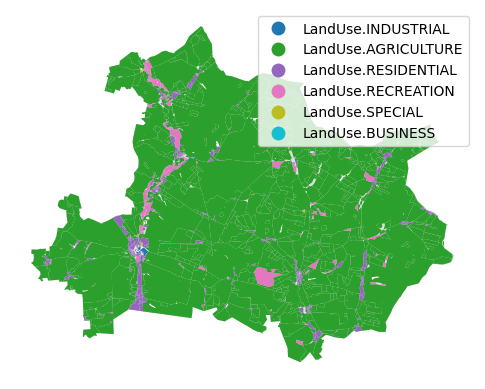

In [19]:
ax = blocks.plot(color='#ddd')
blocks.plot(column='land_use', legend=True, ax=ax).set_axis_off()

___

# **Urbanomy**

In [20]:
from urbanomy.methods.land_value_modeling.land_data_preparation import LandDataPreparator

preparator = LandDataPreparator(
    scenario_blocks_source=blocks,
    context_blocks_source=False,
    predict_project_only=False, 
)

prepared_blocks = preparator.prepare()
prepared_blocks.head()

/Users/mvin/Code/Urbanomy/src/urbanomy/methods/land_value_modeling/land_data_preparation.py:187: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  blocks = pd.concat([scenario, context], ignore_index=True)
2025-12-10 18:21:50.346 | WARNING  | blocksnet.analysis.morphotypes.schemas:_before_validate:17 - Column l not found in columns. Calculating from fsi and gsi


,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,site_area,fsi,gsi,mxi,l,morphotype,area_accessibility,is_project,geometry,id
0,0.000000,0.0,0.000000,0.234148,0.0,0.000000,0.000000,LandUse.INDUSTRIAL,0.234148,12670.609463,...,3.110264e+05,0.067021,0.040738,0.00000,1.645181,low-rise non-residential,454.472112,False,"POLYGON ((542014.088 5485820.799, 542016.654 5...",0
1,0.000000,0.0,0.041061,0.000944,0.0,0.000173,0.762672,LandUse.AGRICULTURE,0.762672,484369.085377,...,2.094765e+07,0.017656,0.023123,0.00000,0.763556,low-rise non-residential,452.400915,False,"POLYGON ((541994.513 5485482.235, 541995.049 5...",1
2,0.515847,0.0,0.000000,0.000000,0.0,0.042781,0.000000,LandUse.RESIDENTIAL,0.515847,13650.569216,...,3.701373e+05,0.015175,0.036880,0.74027,0.411479,individual residential,452.598502,False,"POLYGON ((541994.513 5485482.235, 541993.127 5...",2
3,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.018510,LandUse.AGRICULTURE,0.018510,25327.295344,...,4.367190e+05,0.112610,0.057994,0.00000,1.941737,low-rise non-residential,449.157395,False,"POLYGON ((542070.776 5484744.57, 542091.671 54...",3
4,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,None,NaN,25853.674569,...,3.190264e+05,0.109707,0.081039,0.00000,1.353757,low-rise non-residential,445.309158,False,"POLYGON ((542125.47 5483577.271, 542228.873 54...",4


In [21]:
from catboost import CatBoostRegressor

from urbanomy.methods.land_value_modeling import LandPriceEstimator

model = CatBoostRegressor()
model.load_model('./data/catboost_model.cbm')  # модель на лог-цене

estimator = LandPriceEstimator(
    model=model,
    blocks=prepared_blocks,
)
blocks_pred = estimator.predict()
blocks_pred.head()


,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,fsi,gsi,mxi,l,morphotype,area_accessibility,is_project,geometry,id,land_value
0,0.000000,0.0,0.000000,0.234148,0.0,0.000000,0.000000,LandUse.INDUSTRIAL,0.234148,12670.609463,...,0.067021,0.040738,0.00000,1.645181,low-rise non-residential,454.472112,False,"POLYGON ((542014.088 5485820.799, 542016.654 5...",0,1.840613e+08
1,0.000000,0.0,0.041061,0.000944,0.0,0.000173,0.762672,LandUse.AGRICULTURE,0.762672,484369.085377,...,0.017656,0.023123,0.00000,0.763556,low-rise non-residential,452.400915,False,"POLYGON ((541994.513 5485482.235, 541995.049 5...",1,9.935471e+08
2,0.515847,0.0,0.000000,0.000000,0.0,0.042781,0.000000,LandUse.RESIDENTIAL,0.515847,13650.569216,...,0.015175,0.036880,0.74027,0.411479,individual residential,452.598502,False,"POLYGON ((541994.513 5485482.235, 541993.127 5...",2,2.678752e+08
3,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.018510,LandUse.AGRICULTURE,0.018510,25327.295344,...,0.112610,0.057994,0.00000,1.941737,low-rise non-residential,449.157395,False,"POLYGON ((542070.776 5484744.57, 542091.671 54...",3,2.747454e+08
4,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,None,NaN,25853.674569,...,0.109707,0.081039,0.00000,1.353757,low-rise non-residential,445.309158,False,"POLYGON ((542125.47 5483577.271, 542228.873 54...",4,1.675296e+08


count      2376.000000
mean      92116.442205
std       73678.606005
min         101.312405
25%       36621.291230
50%       73324.831433
75%      126178.717196
max      380627.727921
Name: price_per_sotka, dtype: float64


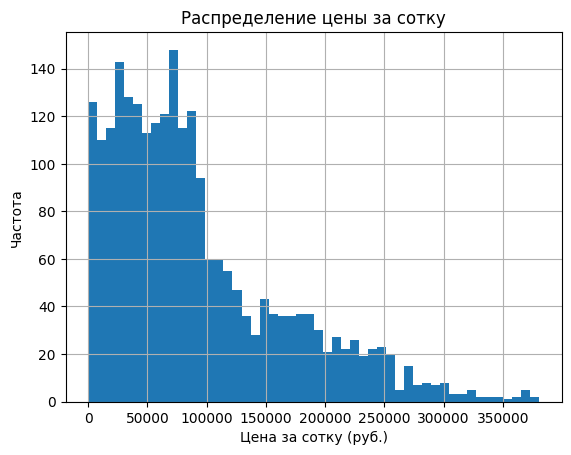

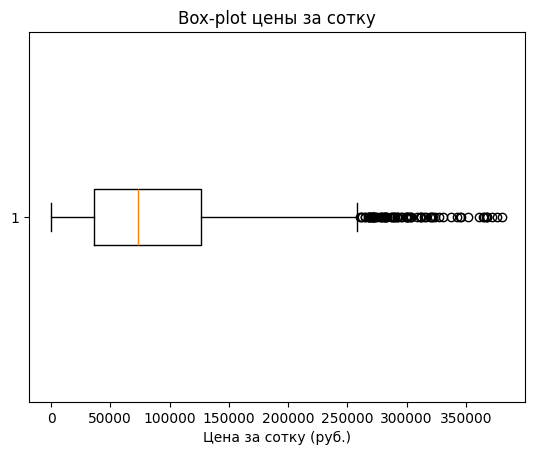

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Цена за сотку (100 м²)
blocks_pred["price_per_sotka"] = blocks_pred["land_value"] / blocks_pred["site_area"] * 100

# 2) Заменяем inf на NaN
blocks_pred["price_per_sotka"] = blocks_pred["price_per_sotka"].replace([np.inf, -np.inf], np.nan)

# 3) Удаляем выбросы: оставляем данные до 99-го перцентиля
p99 = blocks_pred["price_per_sotka"].quantile(0.99)
blocks_clean = blocks_pred[blocks_pred["price_per_sotka"] <= p99].copy()

print(blocks_clean["price_per_sotka"].describe())

# 4) Гистограмма после очистки
plt.figure()
blocks_clean["price_per_sotka"].dropna().hist(bins=50)
plt.xlabel("Цена за сотку (руб.)")
plt.ylabel("Частота")
plt.title("Распределение цены за сотку")
plt.show()

# 5) Box-plot после очистки
plt.figure()
plt.boxplot(blocks_clean["price_per_sotka"].dropna(), vert=False)
plt.xlabel("Цена за сотку (руб.)")
plt.title("Box-plot цены за сотку")
plt.show()


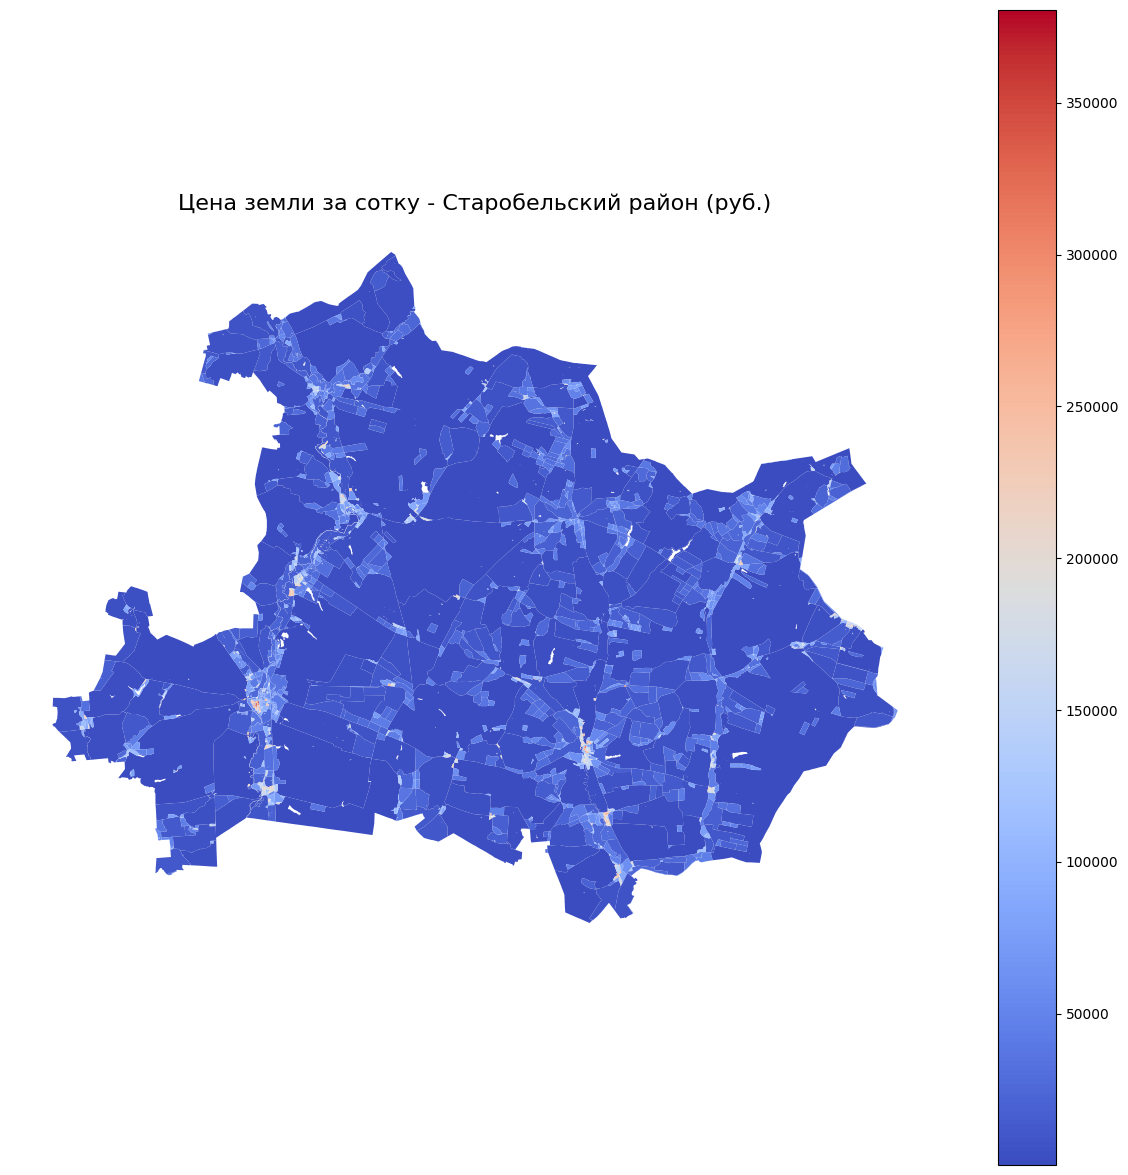

In [25]:
import matplotlib.pyplot as plt

blocks_clean.plot(
    column='price_per_sotka',
    legend=True,
    figsize=(15,15),
    cmap='coolwarm'
).set_axis_off()
plt.title('Цена земли за сотку - Старобельский район (руб.)', fontsize=16)

plt.show()

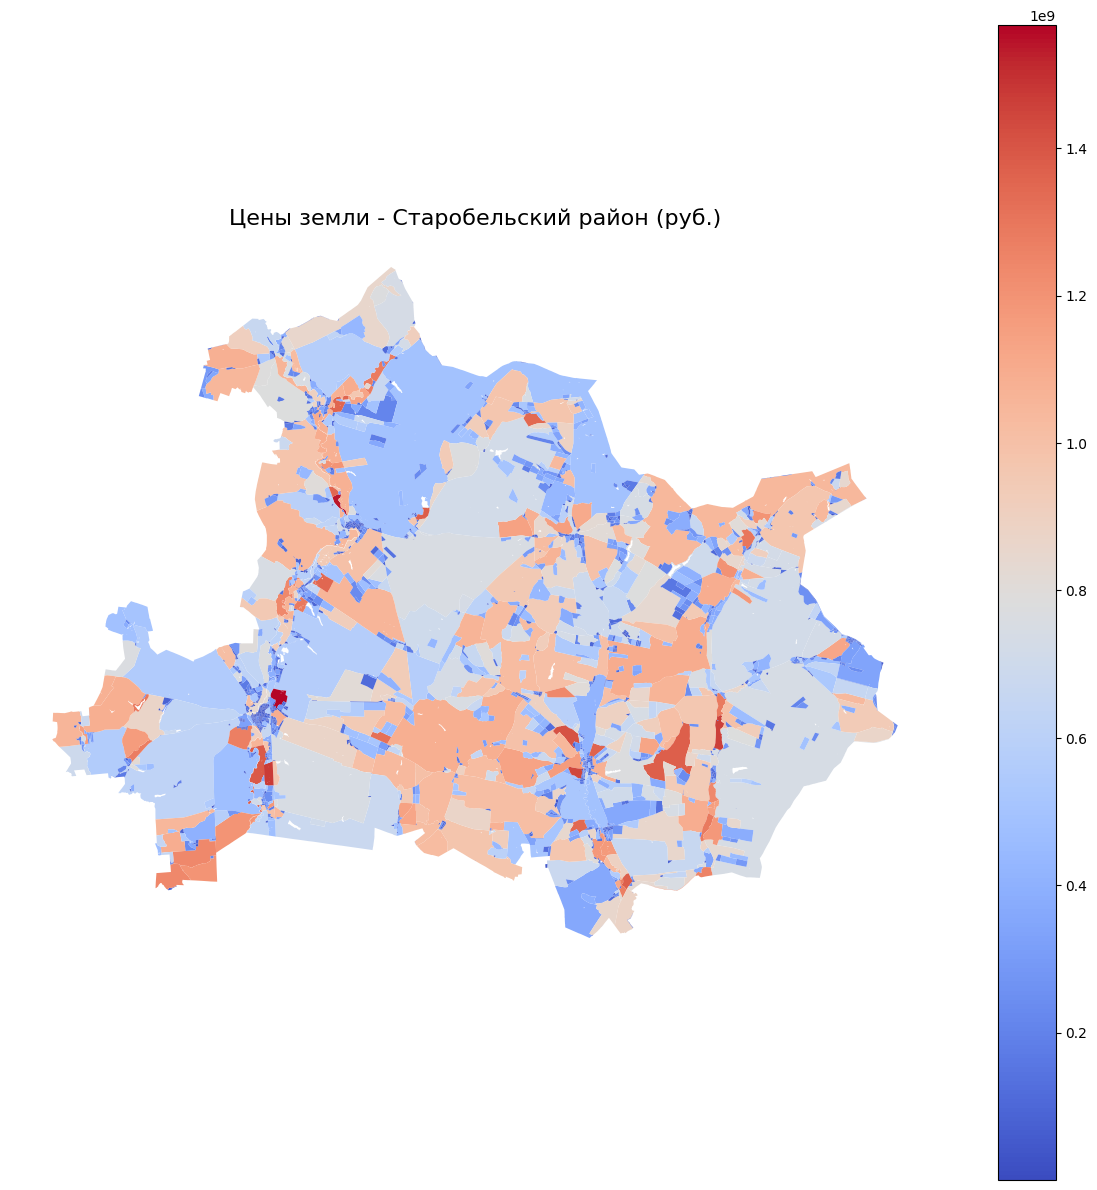

In [26]:
import matplotlib.pyplot as plt

blocks_clean.plot(
    column='land_value',
    legend=True,
    figsize=(15,15),
    cmap='coolwarm'
).set_axis_off()
plt.title('Цены земли - Старобельский район (руб.)', fontsize=16)

plt.show()

In [ ]:
blocks_clean.explore()

In [ ]:
# blocks_clean.to_file('./data/test/staryibel_blocks_with_land_prices.geojson', driver='GeoJSON')

/Users/mvin/Code/Urbanomy/.venv/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: NaN of Infinity value found. Skipped
  ogr_write(


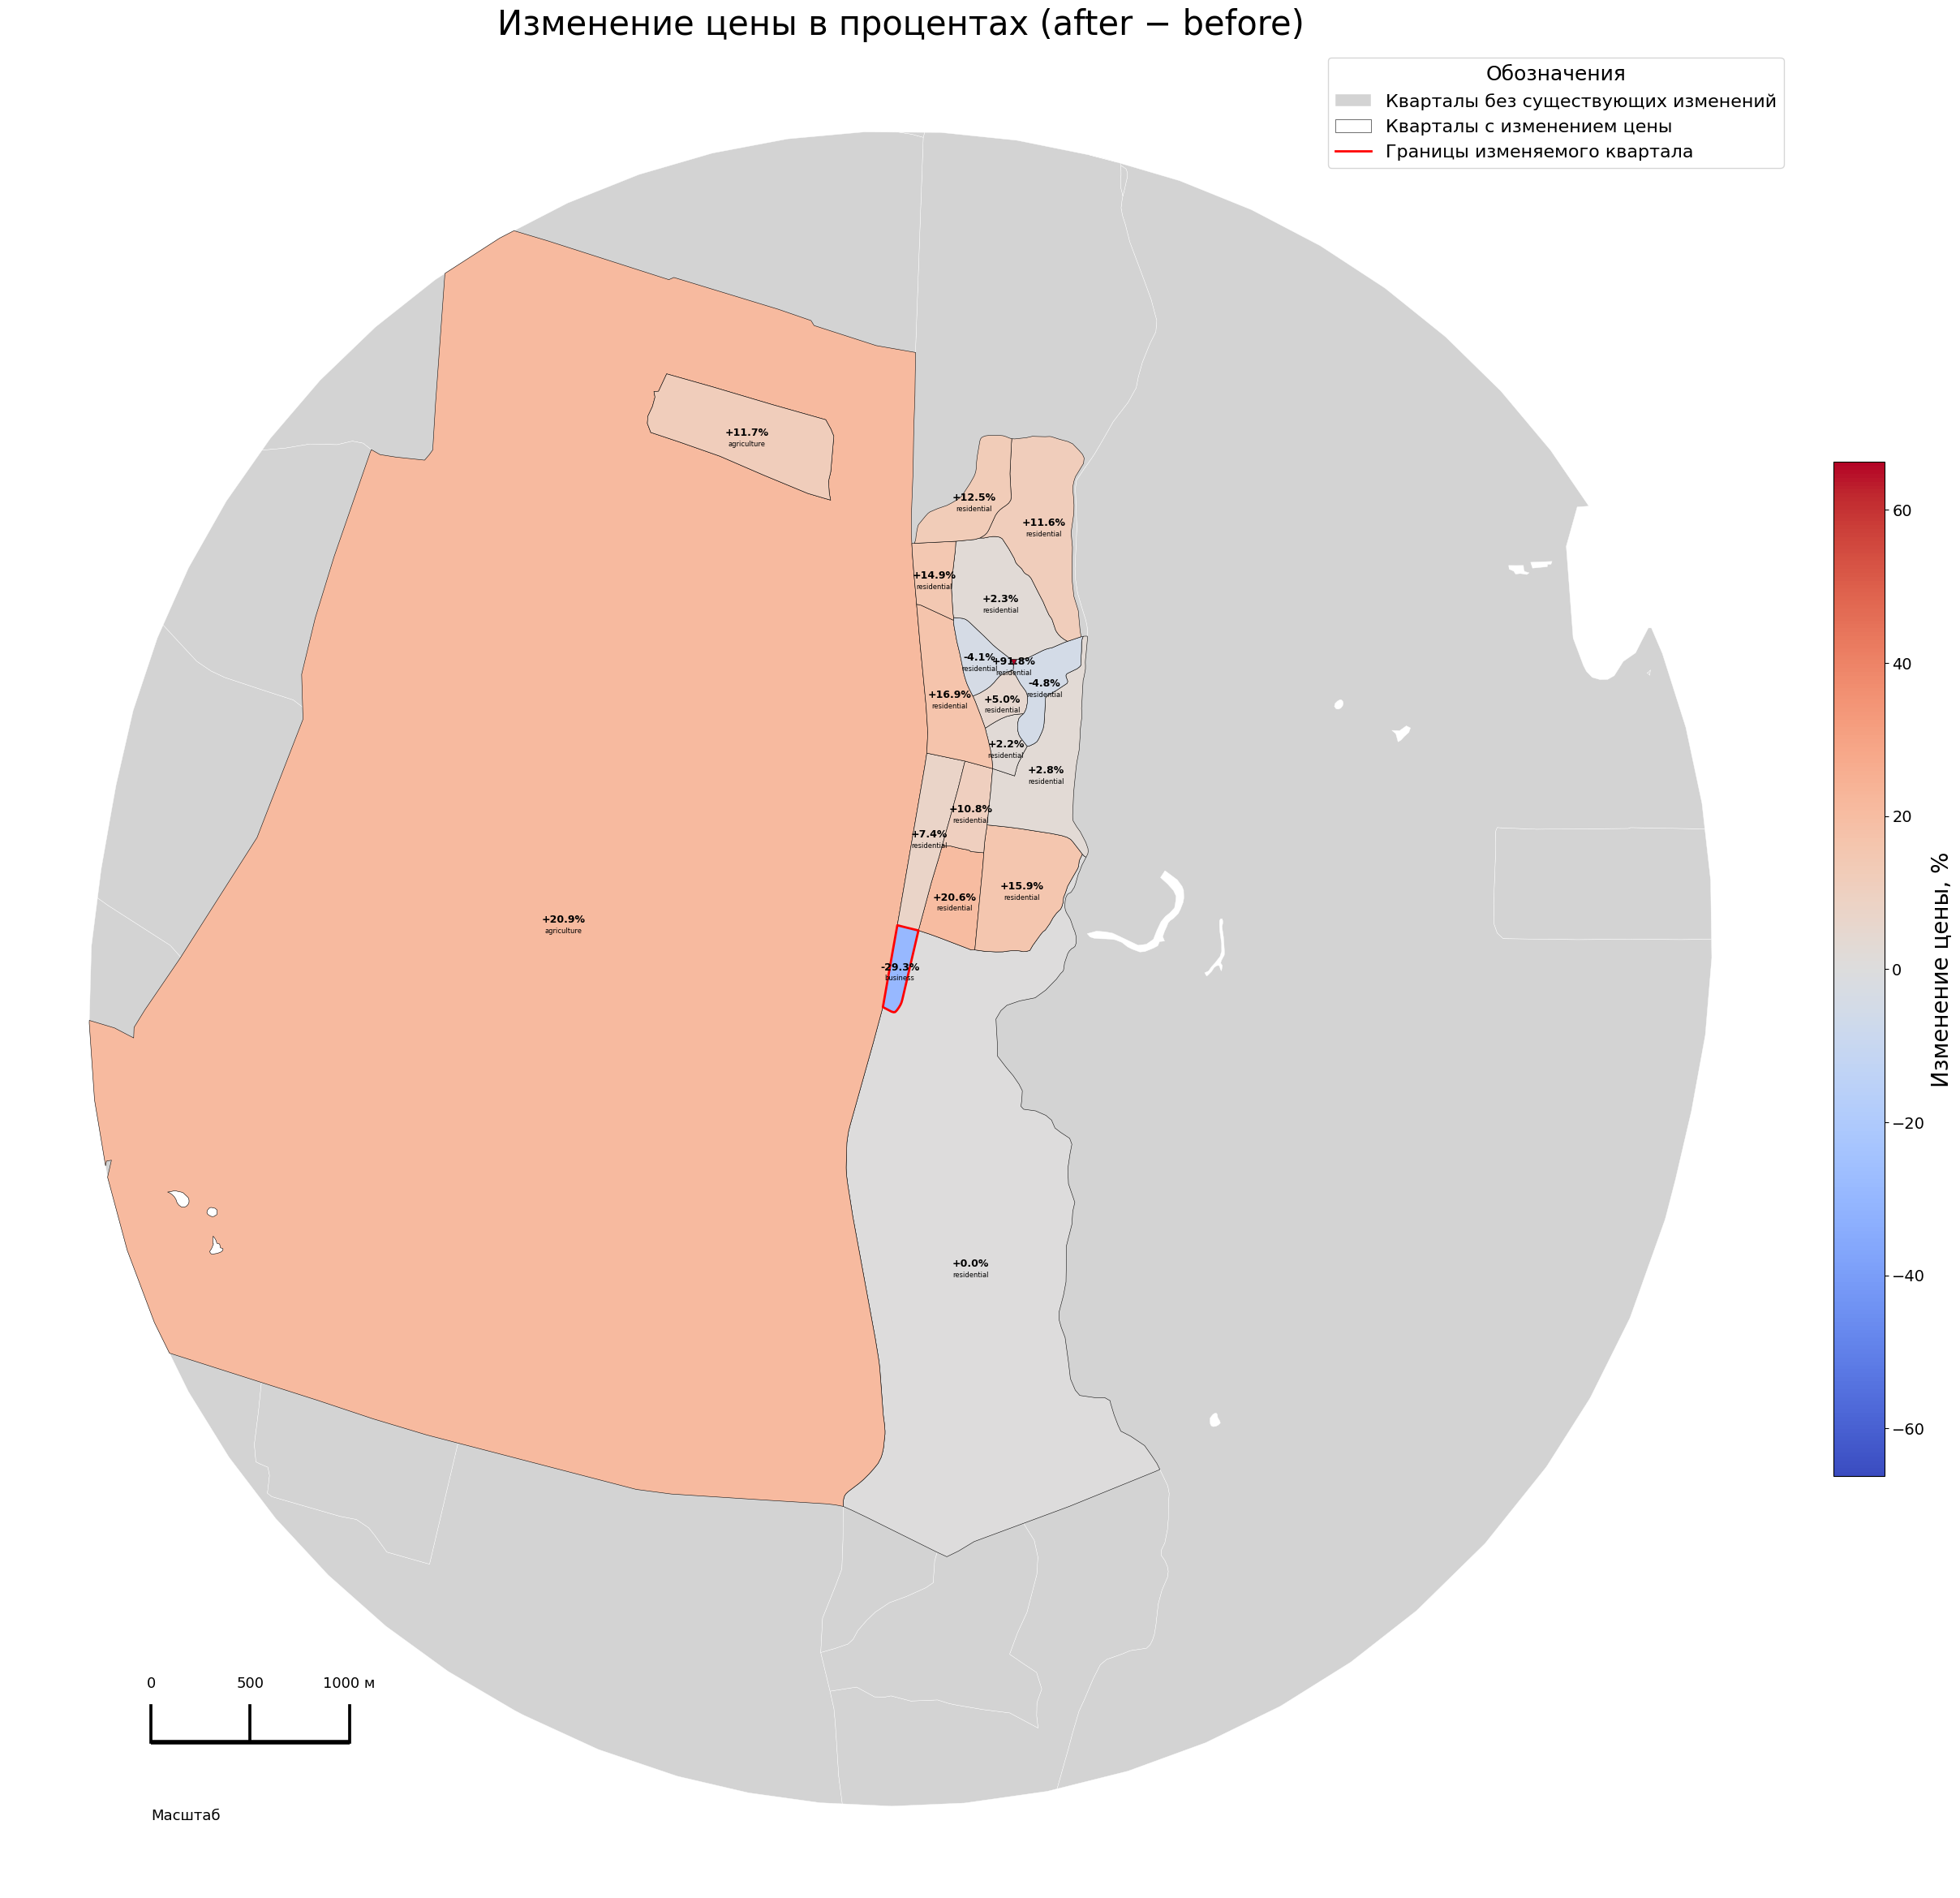


Статистика по кварталам в контексте (|Δ₽| > 1e-09):

Изменяемый квартал:
index | land_use | до (₽) → после (₽) | Δ₽ | Δ%
646 | business | 92 000 682 ₽ → 65 083 969 ₽ | -26 916 713 ₽ | -29.3%

Кварталы в границах проекта:
Нет кварталов проекта с изменениями выше порога.

Кварталы в контексте:
index | land_use | до (₽) → после (₽) | Δ₽ | Δ%
647 | residential | 1 242 278 005 ₽ → 1 242 728 232 ₽ | +450 227 ₽ | +0.0%
2160 | residential | 220 348 643 ₽ → 265 791 879 ₽ | +45 443 237 ₽ | +20.6%
2167 | residential | 393 384 552 ₽ → 455 807 559 ₽ | +62 423 007 ₽ | +15.9%
642 | agriculture | 939 284 605 ₽ → 1 135 297 100 ₽ | +196 012 495 ₽ | +20.9%
645 | residential | 238 691 927 ₽ → 256 407 946 ₽ | +17 716 020 ₽ | +7.4%
2161 | residential | 124 226 056 ₽ → 137 648 193 ₽ | +13 422 137 ₽ | +10.8%
2162 | residential | 146 665 888 ₽ → 150 727 926 ₽ | +4 062 038 ₽ | +2.8%
2163 | residential | 73 442 506 ₽ → 75 054 145 ₽ | +1 611 640 ₽ | +2.2%
2166 | residential | 104 624 858 ₽ → 109 826 932 ₽ | +5 2

In [46]:
from urbanomy.methods.land_value_modeling import (
    ScenarioTEPModifier,
    plot_scenario_impact,
)

blocks_before = blocks_clean
changes = {
    # Функциональное назначение
    'land_use': 'LandUse.BUSINESS',
    'residential': 0.0,
    'business': 1.0,
    'recreation': 0.0,
    'industrial': 0.0,
    'transport': 0.0,
    'special': 0.0,
    'agriculture': 0.0,
    'share': 1.0,

    # Морфология и площади
    'footprint_area': 20_000.0,
    'build_floor_area': 40_000.0,
    'living_area': 0.0,
    'non_living_area': 30_000.0,

    # Плотности (обновляем по формулам)
    'fsi': 0.7942,
    'gsi': 0.0529,
    'mxi': 0.0,

    # Население
    'population': 0.0,

    # Морфотип
    'morphotype': 'high-rise non-residential',
}
target_idx = 646

modifier = ScenarioTEPModifier(blocks_before)
blocks_after = modifier.apply(target_idx, changes)

scenario_result = plot_scenario_impact(
    blocks_before=blocks_before,
    blocks_after=blocks_after,
    model=model,
    target_idx=target_idx,
    figsize=(25, 40),
)

In [47]:
blocks_after = blocks_after.copy()
blocks_after["is_project"] = False
blocks_after.loc[blocks_after["id"] == target_idx, "is_project"] = True

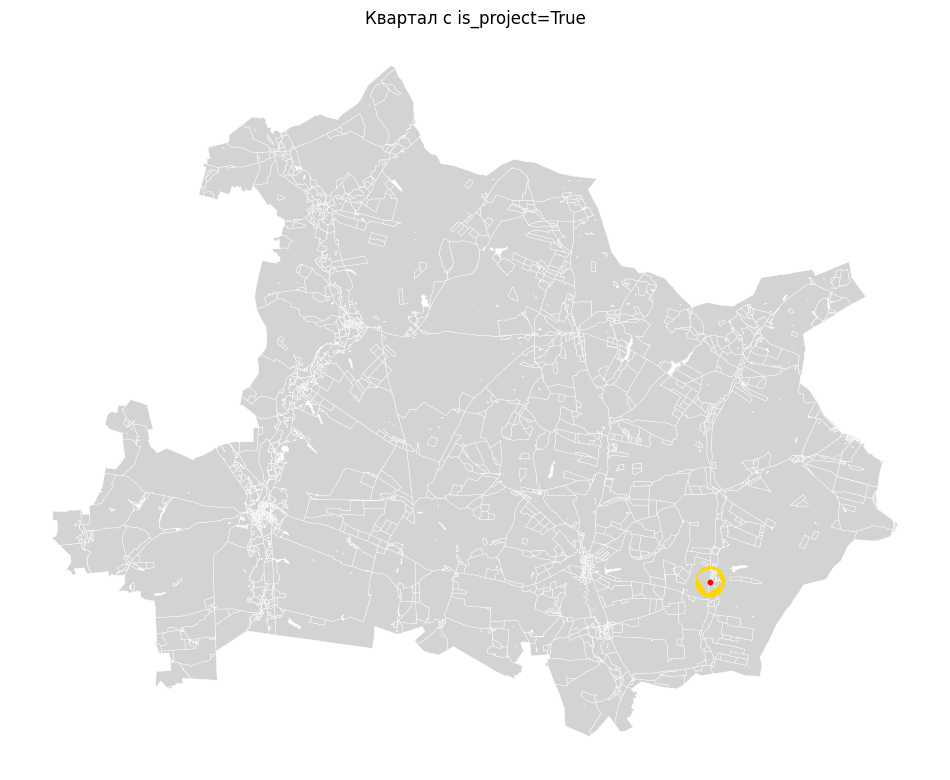

In [50]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 10))
blocks_after.plot(ax=ax, color="lightgrey", edgecolor="white", linewidth=0.3)  # фон
blocks_after.loc[blocks_after["is_project"]].plot(
    ax=ax, color="none", edgecolor="gold", linewidth=20.5
)
blocks_after.loc[blocks_after["is_project"]].centroid.plot(
    ax=ax, color="red", markersize=10, zorder=3
)

ax.set_title("Квартал с is_project=True")
ax.axis("off")
plt.show()

# **Инвестиционная** привлекактельтность 

In [51]:
from blocksnet.enums import LandUse

benchmarks_demo = {
    LandUse.RESIDENTIAL: {
        "cost_build": 45_000,
        "price_sale": 120_000,
        "construction_years": 3,
        "sale_years": 3,
        "opex_rate": 800,
    },
    LandUse.BUSINESS: {
        "cost_build": 55_000,
        "rent_annual": 25_000,
        "rent_years": 12,
        "construction_years": 4,
        "opex_rate": 1_300,
    },
    LandUse.RECREATION: {
        "cost_build": 20_000,
        "rent_annual": 4_500,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 1_000,
    },
    LandUse.SPECIAL: {
        "cost_build": 35_000,
        "rent_annual": 11_000,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 1_500,
    },
    LandUse.INDUSTRIAL: {
        "cost_build": 38_000,
        "rent_annual": 14_800,
        "rent_years": 12,
        "construction_years": 3,
        "opex_rate": 700,
    },
    LandUse.AGRICULTURE: {
        "cost_build": 25_000,
        "rent_annual": 6_500,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 300,
    },
    LandUse.TRANSPORT: {
        "cost_build": 18_000,
        "rent_annual": 6_200,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 600,
    },
}

In [52]:
from urbanomy.methods.investment_potential import prepare_investment_input
import pandas as pd

potential_df = pd.read_csv("./data/land_use_potentials.csv")

investment_input = prepare_investment_input(
    gdf = blocks_after,
    project_potential = potential_df,
)

investment_input.head()

2025-12-10 18:47:40.590 | WARNING  | urbanomy.utils.investment_input:prepare_investment_input:444 - prepare_investment_input: колонка 'land_value_before' не найдена; значения скопированы из 'land_value'.


,land_use,land_value,land_value_before,site_area,living_area,non_living_area,build_floor_area,share,spatial_potential
0,LandUse.BUSINESS,9.200068e+07,9.200068e+07,41247.071742,0.0,30000.0,40000.0,1.0,4.0


In [53]:
from urbanomy.methods.investment_potential import InvestmentAttractivenessAnalyzer

an = InvestmentAttractivenessAnalyzer(benchmarks=benchmarks_demo)
summary = an.calculate_investment_metrics(investment_input, discount_rate=0.18)
summary

Project totals:
 • Land area:          41,247.07
 • Built area:         30,000.00
 • Land value:         92,000,682.35
 • Construction cost:  1,650,000,000.00
 • Investment need:    1,742,000,682.35
 • Spatial potential:  4.00
 • Project NPV:        672,815,325.73
 • Project IRR:        0.26
 • Project ROI:        14.46
 • Project PP (yrs):   9.30
 • Project EI:         82.10
 • Project INV score:  57.47


,land_use,land_area,land_value_before,built_area,land_value,construction_cost,investment_need,NPV,IRR,ROI,PP_years,EI,spatial_potential,INV
0,LandUse.BUSINESS,41247.07,92000682.35,30000.0,92000682.35,1.650000e+09,1.742001e+09,6.728153e+08,0.26,14.46,9.3,82.1,4.0,57.47


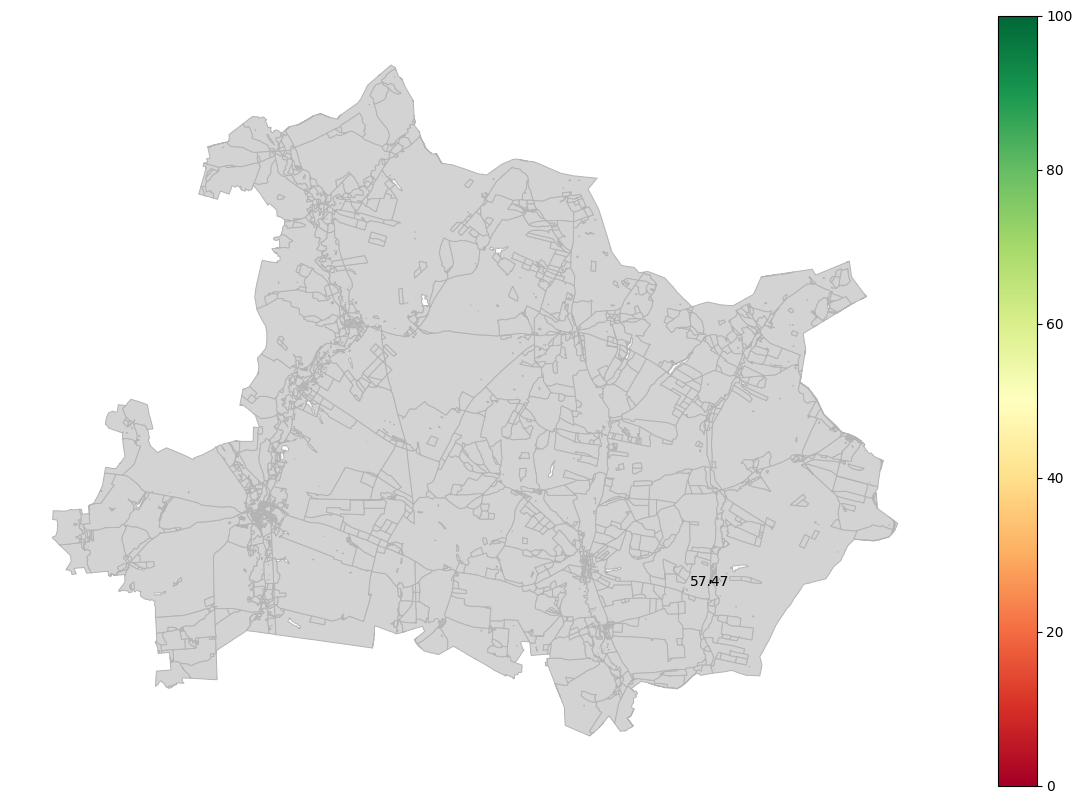

In [54]:
# 1) кладём summary на нужный индекс
summary_idxed = summary.copy()
summary_idxed.index = [target_idx]  # если одна строка; иначе set_index по id

# 2) собираем слой
scn = blocks_after[["geometry"]].join(summary_idxed, how="left")
scn["is_project"] = scn.index == target_idx

column = "INV"
vmin, vmax = 0, 100

fig, ax = plt.subplots(figsize=(15, 10))
scn.loc[~scn["is_project"]].plot(ax=ax, color="lightgrey", edgecolor="0.7", linewidth=0.7)

scn_proj = scn.loc[scn["is_project"]]
if len(scn_proj):
    scn_proj.plot(
        ax=ax,
        column=column,
        cmap="RdYlGn",
        legend=True,
        edgecolor="black",
        linewidth=0.9,
        vmin=vmin,
        vmax=vmax,
    )
    for _, row in scn_proj.dropna(subset=[column]).iterrows():
        x, y = row.geometry.representative_point().coords[0]
        ax.text(x, y, f"{row[column]:.2f}", ha="center", va="center", fontsize=10, color="black")

ax.set_axis_off()
plt.show()

In [55]:
from urbanomy.methods.socio_economic_indicators.sei_calculate import SEREstimator

deafaut_cfg = {
    "population": 300_000,
}

est = SEREstimator(deafaut_cfg) # or use project_cfg
result = est.compute(scn, pretty=True)
result

,indicator,delta_total
0,Объём инвестиций в основной капитал на душу на...,5 500
1,Валовый региональный продукт на душу населения,3 950
2,Доходы бюджета территории,920 891 000
3,Средний уровень заработной платы,129
4,Износ основного фонда (тыс. руб.),47 025
